## **PCD ASSIGMENT #1**
Farrel Fata Varian Nugraha
25/564457/PA/23770

# **Import Library**

In [39]:
import requests
import re
import cv2 as cv
import numpy as np
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

# **Down Sampling Max**

In [40]:
def downsample_max(img):
    tinggi, lebar, warna = img.shape

    out_img = np.zeros((tinggi // 2, lebar // 2, warna), dtype=img.dtype)

    for i in range(out_img.shape[0]):
        for j in range(out_img.shape[1]):
            area = img[i*2 : i*2+2, j*2 : j*2+2]
            out_img[i, j] = np.max(area, axis=(0, 1))

    return out_img

# **Down Sampling Average**

In [41]:
def downsample_avg(img):
    tinggi, lebar, warna = img.shape
    out_img = np.zeros((tinggi // 2, lebar // 2, warna), dtype=img.dtype)

    for baris in range(out_img.shape[0]):
        for kolom in range(out_img.shape[1]):
            area = img[baris*2 : baris*2+2, kolom*2 : kolom*2+2]
            out_img[baris, kolom] = np.mean(area, axis=(0, 1))

    return out_img

# **Down Sampling Medium**

In [42]:
def downsample_median(img):
    tinggi, lebar, warna = img.shape
    out_img = np.zeros((tinggi // 2, lebar // 2, warna), dtype=img.dtype)

    for b in range(out_img.shape[0]):
        for k in range(out_img.shape[1]):
            area = img[b*2 : b*2+2, k*2 : k*2+2]
            out_img[b, k] = np.median(area, axis=(0, 1))

    return out_img

# **Up Sampling NN**

In [43]:
def upsample_nearest(img):
    tinggi, lebar, warna = img.shape
    out_img = np.zeros((tinggi * 2, lebar * 2, warna), dtype=img.dtype)

    for i in range(out_img.shape[0]):
        for j in range(out_img.shape[1]):
            asal_y = i // 2
            asal_x = j // 2
            out_img[i, j] = img[asal_y, asal_x]

    return out_img

# **Up Sampling Bilinear**

In [44]:
def upsample_bilinear(img):
    tinggi, lebar, warna = img.shape
    t_baru, l_baru = tinggi * 2, lebar * 2
    out_img = np.zeros((t_baru, l_baru, warna), dtype=np.float32)

    for i in range(t_baru):
        for j in range(l_baru):
            y_asli = i / 2.0
            x_asli = j / 2.0

            y_bawah = int(np.floor(y_asli))
            x_kiri = int(np.floor(x_asli))
            y_atas = min(y_bawah + 1, tinggi - 1)
            x_kanan = min(x_kiri + 1, lebar - 1)

            jarak_y = y_asli - y_bawah
            jarak_x = x_asli - x_kiri

            pixel_atas = img[y_bawah, x_kiri] * (1 - jarak_x) + img[y_bawah, x_kanan] * jarak_x
            pixel_bawah = img[y_atas, x_kiri] * (1 - jarak_x) + img[y_atas, x_kanan] * jarak_x

            out_img[i, j] = pixel_atas * (1 - jarak_y) + pixel_bawah * jarak_y

    return np.clip(out_img, 0, 255).astype(img.dtype)

# **Up Sampling Bicubic**

In [45]:
def upsample_bicubic(img):
    tinggi, lebar = img.shape[:2]
    out_img = cv.resize(img, (lebar * 2, tinggi * 2), interpolation=cv.INTER_CUBIC)
    return out_img

# **MAIN**

In [46]:
def tampilkan_hasil(gambar_asli, daftar_hasil, daftar_judul):
    plt.figure(figsize=(15, 5))
    semua_gambar = [gambar_asli] + daftar_hasil
    semua_judul = ["Original"] + daftar_judul

    jumlah = len(semua_gambar)
    for idx in range(jumlah):
        plt.subplot(1, jumlah, idx + 1)
        plt.imshow(semua_gambar[idx])
        plt.title(semua_judul[idx])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def jalankan_percobaan(gambar):
    img_array = np.array(gambar)
    img_rgb = cv.cvtColor(img_array, cv.COLOR_BGR2RGB)

    hasil_down = [
        downsample_max(img_rgb),
        downsample_avg(img_rgb),
        downsample_median(img_rgb)
    ]
    tampilkan_hasil(img_rgb, hasil_down, ["Max", "Avg", "Medium"])

    hasil_up = [
        upsample_nearest(img_rgb),
        upsample_bilinear(img_rgb),
        upsample_bicubic(img_rgb)
    ]
    tampilkan_hasil(img_rgb, hasil_up, ["NN", "Bilinear", "Bicubic"])

# **Image Load**

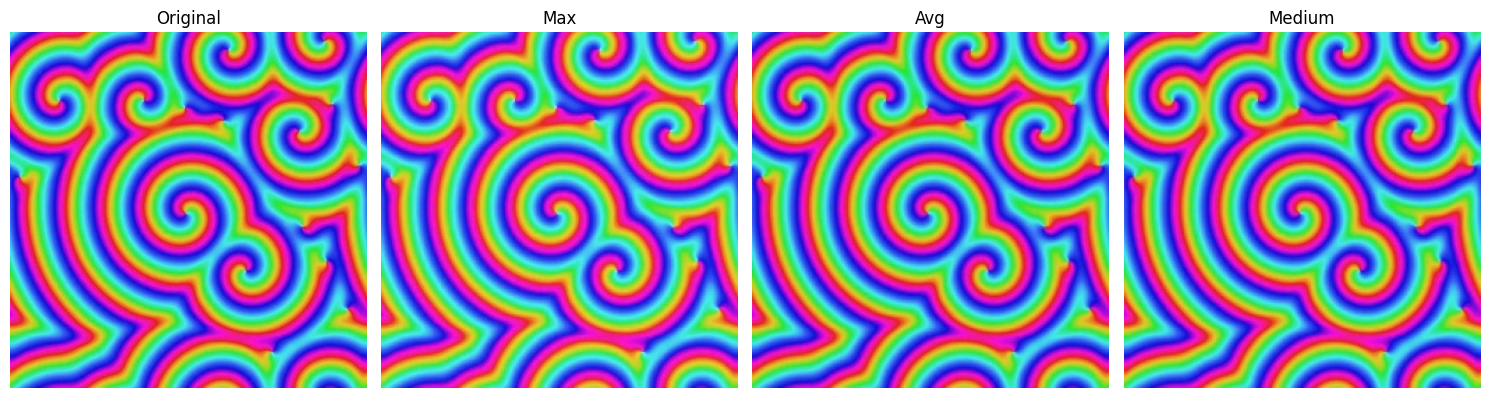

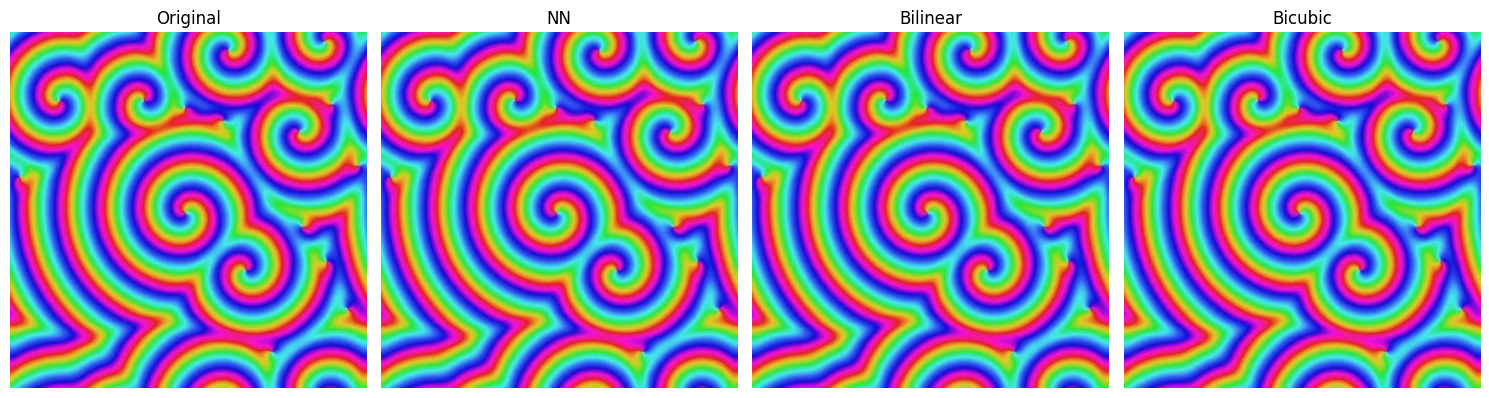

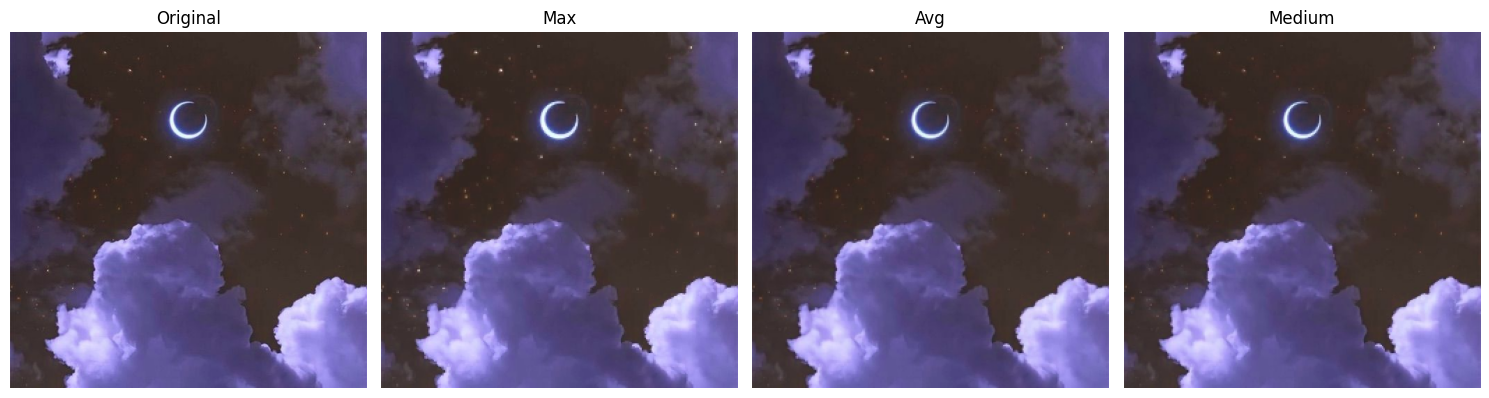

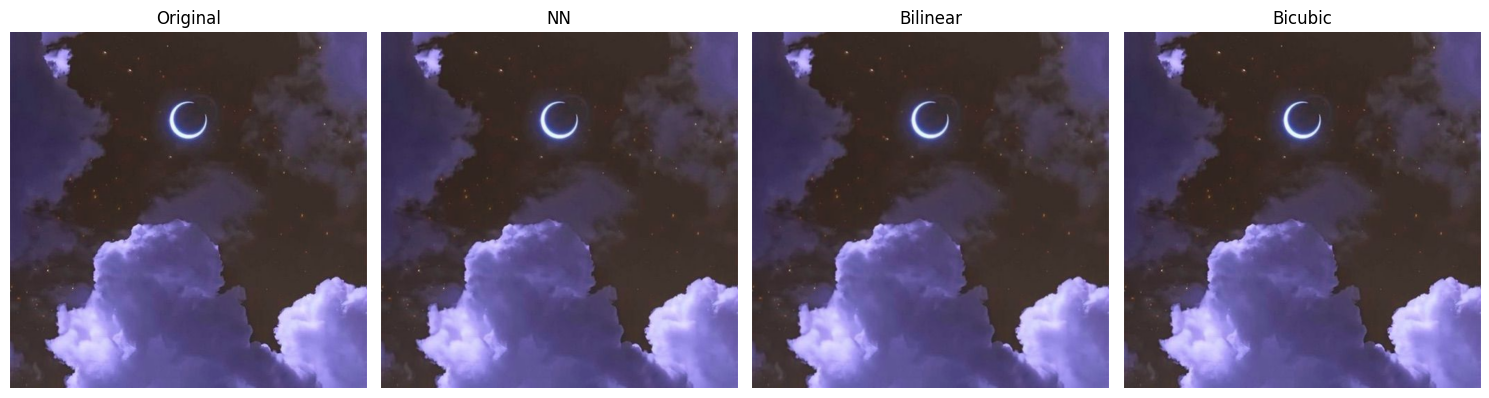

In [47]:
daftar_link = [
    "https://drive.google.com/file/d/1iCPeYrRwCPAlGFNgBTVmamkOuhn4uKl3/view?usp=sharing",
    "https://drive.google.com/file/d/1hd9PQMCgQIICemdpc-PQiFnP1AkLtQT7/view?usp=sharing"
]

def unduh_dan_resize(link_drive, ukuran=(512, 512)):
    id_file = re.search(r"/d/([^/]+)", link_drive).group(1)
    url_unduh = f"https://drive.google.com/uc?export=download&id={id_file}"

    resp = requests.get(url_unduh)
    resp.raise_for_status()

    img_obj = Image.open(BytesIO(resp.content))
    img_resized = img_obj.resize(ukuran)

    return img_resized

for link in daftar_link:
    img_siap = unduh_dan_resize(link)
    jalankan_percobaan(img_siap)